In [1]:
import pandas as pd
import numpy as np

# Simulate a churn dataset with different values
np.random.seed(2026)
n = 1500
data = pd.DataFrame({
    'gender': np.random.choice(['Male', 'Female'], n),
    'SeniorCitizen': np.random.choice([0, 1], n, p=[0.85, 0.15]),
    'Partner': np.random.choice(['Yes', 'No'], n, p=[0.4, 0.6]),
    'Dependents': np.random.choice(['Yes', 'No'], n, p=[0.25, 0.75]),
    'tenure': np.random.randint(0, 72, n),
    'PhoneService': np.random.choice(['Yes', 'No'], n, p=[0.88, 0.12]),
    'InternetService': np.random.choice(['DSL', 'Fiber optic', 'No'], n, p=[0.35, 0.45, 0.20]),
    'MonthlyCharges': np.random.uniform(15, 150, n),
    'TotalCharges': np.random.uniform(10, 10000, n),
    'Churn': np.random.choice(['Yes', 'No'], n, p=[0.25, 0.75])
})

print(data.head())


   gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0      No         No      13          Yes   
1    Male              0     Yes         No      39          Yes   
2    Male              0     Yes         No      14          Yes   
3    Male              1     Yes         No      57          Yes   
4  Female              0     Yes        Yes      63          Yes   

  InternetService  MonthlyCharges  TotalCharges Churn  
0     Fiber optic      115.403624   8725.500689    No  
1             DSL      127.120227   8633.843980    No  
2     Fiber optic       93.137607   2525.263974   Yes  
3     Fiber optic       58.321625   8224.269591    No  
4             DSL      149.752511   3222.833321   Yes  


In [3]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
for col in ['gender','Partner','Dependents','PhoneService','InternetService','Churn']:
    le = LabelEncoder()
    data[col] = le.fit_transform(data[col])

# Features and target
X = data.drop('Churn', axis=1)
y = data['Churn']

# Train-test split with different test size and seed
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=2026, stratify=y)


In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

# Train Logistic Regression with a larger max_iter
log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

# Train Random Forest with different number of estimators and seed
rf = RandomForestClassifier(n_estimators=150, random_state=2026)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

# Print classification reports
print('Logistic Regression Report:\n', classification_report(y_test, y_pred_log))
print('Random Forest Report:\n', classification_report(y_test, y_pred_rf))


Logistic Regression Report:
               precision    recall  f1-score   support

           0       0.75      1.00      0.86       281
           1       0.00      0.00      0.00        94

    accuracy                           0.75       375
   macro avg       0.37      0.50      0.43       375
weighted avg       0.56      0.75      0.64       375

Random Forest Report:
               precision    recall  f1-score   support

           0       0.74      0.95      0.84       281
           1       0.13      0.02      0.04        94

    accuracy                           0.72       375
   macro avg       0.44      0.49      0.44       375
weighted avg       0.59      0.72      0.64       375



C:\Users\Owner\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Owner\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\Owner\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


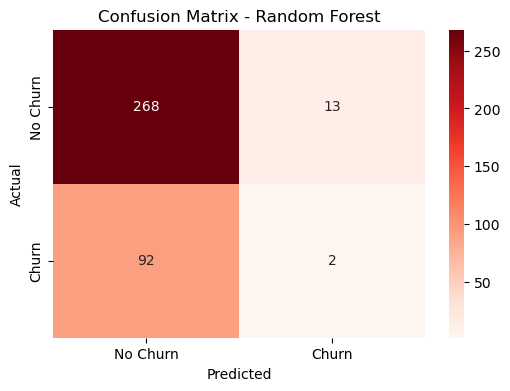

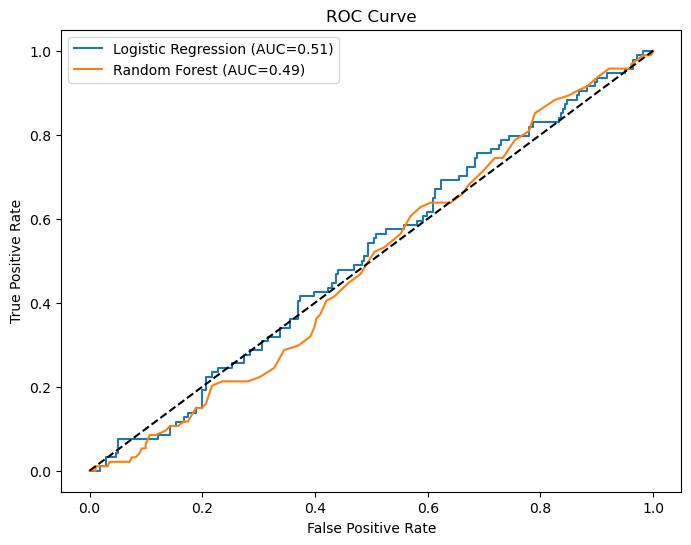

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, roc_curve, auc

# Confusion Matrix for Random Forest
cm = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ROC Curve
y_prob_log = log_reg.predict_proba(X_test)[:, 1]
y_prob_rf = rf.predict_proba(X_test)[:, 1]

fpr_log, tpr_log, _ = roc_curve(y_test, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))
plt.plot(fpr_log, tpr_log, label=f'Logistic Regression (AUC={auc(fpr_log, tpr_log):.2f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc(fpr_rf, tpr_rf):.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()


T-test p-value: 0.044744966572884334
Chi-square p-value: 0.05396075991199039


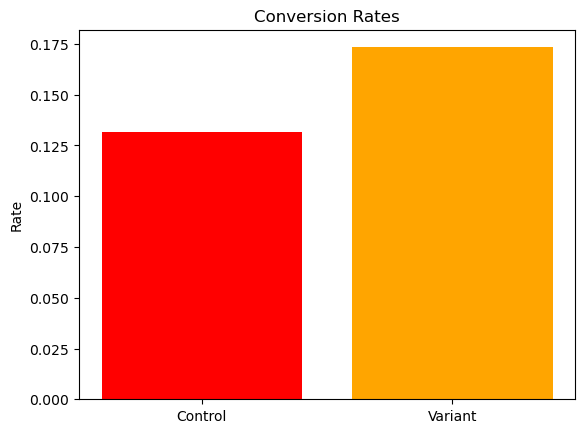

In [13]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind, chi2_contingency
import matplotlib.pyplot as plt

# Simulate conversion data with different sizes and rates
np.random.seed(2026)
control = np.random.binomial(1, 0.12, 600)  # 12% conversion
variant = np.random.binomial(1, 0.17, 600)  # 17% conversion

# t-test
stat, pval = ttest_ind(control, variant)
print(f'T-test p-value: {pval}')

# Chi-square test
contingency_table = pd.DataFrame({
    'Converted': [control.sum(), variant.sum()],
    'Not Converted': [len(control)-control.sum(), len(variant)-variant.sum()]
}, index=['Control','Variant'])
chi2, chi_p, _, _ = chi2_contingency(contingency_table)
print(f'Chi-square p-value: {chi_p}')

# Visualization
conv_rates = [control.mean(), variant.mean()]
plt.bar(['Control','Variant'], conv_rates, color=['Red','Orange'])
plt.title('Conversion Rates')
plt.ylabel('Rate')
plt.show()
